# HBL BiLSTM + Attention Classification — Research Paper Version (v4)
## AI-Driven Stock Prediction with Sentiment Analysis

**Fixes applied vs v3 (based on critical review):**
1. ✅ Rolling features computed **train-only**, projected forward — no leakage
2. ✅ Sentiment features **lagged by 1 day** (news processed before market close assumption removed)
3. ✅ Ablation uses **consistent thresholds** — both models tuned on val set  
4. ✅ **McNemar's test** added for statistical significance of sentiment uplift
5. ✅ `recurrent_dropout=0` — CuDNN kernel enabled for speed
6. ✅ `DROPOUT_RATE=0.15` — reduced to avoid underfitting on ~1600 sequences
7. ✅ `GlobalMaxPooling1D + GlobalAveragePooling1D` concat — preserves temporal signal
8. ✅ **Walk-forward validation** (5 expanding windows) added alongside single-split
9. ✅ **Logistic Regression baseline** added to ablation table
10. ✅ Feature importance uses **validation set**, not test set
11. ✅ Backtest is **long-only** (no short selling — PSX constraint)
12. ✅ Annualised return and win-rate added to backtest metrics

**Dataset:** HBL (Habib Bank Limited) — PSX | 2016–2025  
**Sentiment source:** Dawn News (daily, quarterly, annual)  
**Task:** 5-day forward direction classification (UP=1 / DOWN=0)

## Section 1 — Imports & Configuration

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from statsmodels.stats.contingency_tables import mcnemar
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix, roc_curve
)
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Bidirectional, LSTM, Dense, Dropout,
    LayerNormalization, MultiHeadAttention,
    GlobalAveragePooling1D, GlobalMaxPooling1D, Concatenate
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
import warnings, os, pickle
warnings.filterwarnings('ignore')

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ── Configuration ─────────────────────────────────────────────────────────────
SEQUENCE_LENGTH = 30       # Days of history per sample
FORWARD_DAYS    = 5        # Predict 5-day cumulative direction
LSTM_UNITS_1    = 128
LSTM_UNITS_2    = 64
ATTN_HEADS      = 4
ATTN_KEY_DIM    = 32
DROPOUT_RATE    = 0.15     # FIX: reduced from 0.3 — prevents underfitting on ~1600 seqs
LEARNING_RATE   = 1e-3
BATCH_SIZE      = 32
MAX_EPOCHS      = 100
TRAIN_RATIO     = 0.70
VAL_RATIO       = 0.15
SENTIMENT_LAG   = 1        # FIX: lag sentiment by 1 day (no same-day look-ahead)

# ── Paths — UPDATE THESE ──────────────────────────────────────────────────────
DATA_PATH        = 'hbl_merged_dataset_clean.csv'
OUTPUT_DIR       = '.'
MODEL_FULL_PATH  = os.path.join(OUTPUT_DIR, 'bilstm_clf_full_v4.keras')
MODEL_PRICE_PATH = os.path.join(OUTPUT_DIR, 'bilstm_clf_price_v4.keras')
ARTIFACTS_PATH   = os.path.join(OUTPUT_DIR, 'artifacts_v4.pkl')

os.makedirs(OUTPUT_DIR, exist_ok=True)

print('✅ Libraries loaded')
print(f'   TensorFlow : {tf.__version__}')
print(f'   Task       : {FORWARD_DAYS}-day direction classification (UP / DOWN)')
print(f'   Sequence   : {SEQUENCE_LENGTH} days lookback')
print(f'   Sentiment lag: {SENTIMENT_LAG} day(s)')

✅ Libraries loaded
   TensorFlow : 2.20.0
   Task       : 5-day direction classification (UP / DOWN)
   Sequence   : 30 days lookback
   Sentiment lag: 1 day(s)


## Section 2 — Load & Validate Data

In [5]:
df = pd.read_csv(DATA_PATH, parse_dates=['date'])
df = df.sort_values('date').reset_index(drop=True)
print(f'Loaded {len(df)} rows  |  {df["date"].min().date()} → {df["date"].max().date()}')
print(f'Columns: {df.columns.tolist()}')
print(f'\nClass distribution (direction_next):')
vc = df['direction_next'].value_counts()
print(f'  UP   (1): {vc.get(1,0):4d} ({vc.get(1,0)/len(df):.1%})')
print(f'  DOWN (0): {vc.get(0,0):4d} ({vc.get(0,0)/len(df):.1%})')
print(f'\nMissing values:')
print(df.isnull().sum()[df.isnull().sum()>0])

Loaded 2503 rows  |  2015-12-31 → 2025-08-28
Columns: ['date', 'Open', 'High', 'Low', 'Close', 'Volume', 'daily_sentiment', 'daily_sentiment_sum', 'daily_news_count', 'daily_pos', 'daily_neg', 'daily_neu', 'quarterly_sentiment', 'annual_sentiment', 'log_return', 'close_next', 'log_return_next', 'direction_next', 'quarterly_date', 'annual_date']

Class distribution (direction_next):
  UP   (1): 1133 (45.3%)
  DOWN (0): 1370 (54.7%)

Missing values:
Series([], dtype: int64)


## Section 3 — Leak-Free Feature Engineering

> **Key fix:** All rolling features are computed **only on training data** then projected forward using `transform()`. This prevents future data from bleeding into past features near split boundaries.

In [6]:
# ════════════════════════════════════════════════════════════
# STEP 1: Compute RAW features that don't depend on split boundaries
# (price ratios, lagged returns, EWM — these are genuinely point-in-time)
# ════════════════════════════════════════════════════════════

# Returns (log — point-in-time, no rolling contamination)
df['ret_1']  = df['log_return']

# ATR-14 (normalised — uses only past prices, EWM-style)
hl   = df['High'] - df['Low']
hc   = (df['High'] - df['Close'].shift(1)).abs()
lc   = (df['Low']  - df['Close'].shift(1)).abs()
tr   = pd.concat([hl, hc, lc], axis=1).max(axis=1)
df['atr_14_raw'] = tr.rolling(14).mean() / (df['Close'] + 1e-9)

# Bollinger Bands (price ratio — we compute sma20 globally but
# we ONLY use the price POSITION within bands, which is not a rolling stat)
sma20_raw = df['Close'].rolling(20).mean()
bb_std_raw = df['Close'].rolling(20).std()
bb_upper_raw = sma20_raw + 2 * bb_std_raw
bb_lower_raw = sma20_raw - 2 * bb_std_raw
df['bb_pos_raw']   = (df['Close'] - bb_lower_raw) / (bb_upper_raw - bb_lower_raw + 1e-9)
df['bb_width_raw'] = (bb_upper_raw - bb_lower_raw) / (sma20_raw + 1e-9)

# RSI-14 (EWM-based — past data only)
delta = df['Close'].diff()
gain  = delta.clip(lower=0).ewm(com=13, adjust=False).mean()
loss  = (-delta.clip(upper=0)).ewm(com=13, adjust=False).mean()
df['rsi_14'] = 1 - 1 / (1 + gain / (loss + 1e-9))

# MACD (EWM — past data only)
ema12 = df['Close'].ewm(span=12, adjust=False).mean()
ema26 = df['Close'].ewm(span=26, adjust=False).mean()
df['macd']        = (ema12 - ema26) / (df['Close'] + 1e-9)
df['macd_signal'] = df['macd'].ewm(span=9, adjust=False).mean()
df['macd_hist']   = df['macd'] - df['macd_signal']

# Intraday range
df['intraday_range'] = (df['High'] - df['Low']) / (df['Close'] + 1e-9)

# Price/news raw ratios
total_articles = df['daily_pos'] + df['daily_neg'] + df['daily_neu'] + 1e-9
df['pos_ratio']     = df['daily_pos'] / total_articles
df['neg_ratio']     = df['daily_neg'] / total_articles
df['sent_polarity'] = df['pos_ratio'] - df['neg_ratio']

# ════════════════════════════════════════════════════════════
# FIX: Lag sentiment by 1 day — assume news impacts NEXT day
# This removes same-day look-ahead bias
# ════════════════════════════════════════════════════════════
df['daily_sentiment_lag1']   = df['daily_sentiment'].shift(SENTIMENT_LAG)
df['quarterly_sentiment_lag1'] = df['quarterly_sentiment'].shift(SENTIMENT_LAG)
df['annual_sentiment_lag1']  = df['annual_sentiment'].shift(SENTIMENT_LAG)
df['pos_ratio_lag1']         = df['pos_ratio'].shift(SENTIMENT_LAG)
df['neg_ratio_lag1']         = df['neg_ratio'].shift(SENTIMENT_LAG)
df['sent_polarity_lag1']     = df['sent_polarity'].shift(SENTIMENT_LAG)
df['news_count_lag1']        = df['daily_news_count'].shift(SENTIMENT_LAG)

# ════════════════════════════════════════════════════════════
# STEP 2: Chronological split BEFORE computing any rolling stats
# Rolling stats will be computed separately per split to prevent leakage
# ════════════════════════════════════════════════════════════

# Drop NaN from raw engineered cols
RAW_COLS = [
    'ret_1', 'atr_14_raw', 'bb_pos_raw', 'bb_width_raw', 'rsi_14',
    'macd', 'macd_signal', 'macd_hist', 'intraday_range',
    'daily_sentiment_lag1', 'quarterly_sentiment_lag1', 'annual_sentiment_lag1',
    'pos_ratio_lag1', 'neg_ratio_lag1', 'sent_polarity_lag1', 'news_count_lag1',
    'Close', 'Volume', 'log_return', 'date'
]
df_raw = df[RAW_COLS + ['direction_next']].dropna().reset_index(drop=True)
n = len(df_raw)

train_end = int(n * TRAIN_RATIO)
val_end   = int(n * (TRAIN_RATIO + VAL_RATIO))

train_raw = df_raw.iloc[:train_end].reset_index(drop=True)
val_raw   = df_raw.iloc[train_end:val_end].reset_index(drop=True)
test_raw  = df_raw.iloc[val_end:].reset_index(drop=True)

print(f'Train : {len(train_raw):4d} rows  {train_raw["date"].min().date()} → {train_raw["date"].max().date()}')
print(f'Val   : {len(val_raw):4d} rows  {val_raw["date"].min().date()} → {val_raw["date"].max().date()}')
print(f'Test  : {len(test_raw):4d} rows  {test_raw["date"].min().date()} → {test_raw["date"].max().date()}')

Train : 1738 rows  2016-01-27 → 2022-09-26
Val   :  373 rows  2022-09-27 → 2024-03-01
Test  :  373 rows  2024-03-04 → 2025-08-28


In [7]:
# ════════════════════════════════════════════════════════════
# STEP 3: Compute rolling features ON TRAIN ONLY
# Then manually forward-fill onto val/test using train statistics
# ════════════════════════════════════════════════════════════

def add_rolling_features(df_split, ref_df=None):
    """
    Compute rolling features. If ref_df is provided (for val/test),
    we concatenate the END of ref_df with df_split and only keep
    df_split rows at the end — this correctly propagates rolling windows
    across the split boundary without leaking future values.
    """
    LOOKBACK = 50  # Enough to initialise any rolling window
    
    if ref_df is not None:
        combined = pd.concat([ref_df.tail(LOOKBACK), df_split], ignore_index=True)
        offset = LOOKBACK  # rows to discard at the front
    else:
        combined = df_split.copy()
        offset = 0

    c = combined.copy()
    
    # Rolling returns — computed locally, no cross-split contamination
    c['ret_5']  = c['log_return'].rolling(5).sum()
    c['ret_10'] = c['log_return'].rolling(10).sum()
    c['ret_20'] = c['log_return'].rolling(20).sum()
    
    # Volatility
    c['vol_5']  = c['log_return'].rolling(5).std()
    c['vol_10'] = c['log_return'].rolling(10).std()
    c['vol_20'] = c['log_return'].rolling(20).std()
    
    # Moving average momentum
    c['sma_10'] = c['Close'].rolling(10).mean()
    c['sma_20'] = c['Close'].rolling(20).mean()
    c['sma_50'] = c['Close'].rolling(50).mean()
    c['mom_10'] = (c['Close'] - c['sma_10']) / (c['sma_10'] + 1e-9)
    c['mom_20'] = (c['Close'] - c['sma_20']) / (c['sma_20'] + 1e-9)
    c['mom_50'] = (c['Close'] - c['sma_50']) / (c['sma_50'] + 1e-9)
    
    # Volume ratio
    c['vol_ratio'] = c['Volume'] / (c['Volume'].rolling(20).mean() + 1e-9)
    
    # Volume-return correlation (FIX: rolling correlation computed locally)
    c['vol_ret_corr'] = c['log_return'].rolling(10).corr(c['Volume'].pct_change())
    
    # Sentiment rolling features (on lagged sentiment — no look-ahead)
    c['sent_mean_10']  = c['daily_sentiment_lag1'].rolling(10).mean()
    c['sent_surprise'] = c['daily_sentiment_lag1'] - c['sent_mean_10']
    c['sent_ma3']      = c['daily_sentiment_lag1'].rolling(3).mean()
    c['sent_ma7']      = c['daily_sentiment_lag1'].rolling(7).mean()
    c['sent_momentum'] = c['sent_ma3'] - c['sent_ma7']
    c['sent_vol']      = c['daily_sentiment_lag1'].rolling(10).std()
    c['news_vol_ratio'] = c['news_count_lag1'] / (c['news_count_lag1'].rolling(20).mean() + 1e-9)

    # Return only the original split rows (not the warm-up prefix)
    return c.iloc[offset:].reset_index(drop=True)

train_fe = add_rolling_features(train_raw, ref_df=None)
val_fe   = add_rolling_features(val_raw,   ref_df=train_raw)
test_fe  = add_rolling_features(test_raw,  ref_df=pd.concat([train_raw, val_raw], ignore_index=True))

print('✅ Rolling features computed (train-only seeding)')
print(f'Train after rolling FE: {len(train_fe)} rows')
print(f'Val   after rolling FE: {len(val_fe)} rows')
print(f'Test  after rolling FE: {len(test_fe)} rows')

# ════════════════════════════════════════════════════════════
# Define feature sets
# ════════════════════════════════════════════════════════════
PRICE_FEATURES = [
    'ret_1', 'ret_5', 'ret_10', 'ret_20',
    'vol_5', 'vol_10', 'vol_20', 'atr_14_raw',
    'mom_10', 'mom_20', 'mom_50',
    'rsi_14', 'bb_width_raw', 'bb_pos_raw',
    'macd', 'macd_signal', 'macd_hist',
    'vol_ratio', 'vol_ret_corr', 'intraday_range',
]

SENTIMENT_FEATURES = [
    'daily_sentiment_lag1',
    'sent_surprise',
    'sent_momentum',
    'sent_vol',
    'sent_polarity_lag1',
    'pos_ratio_lag1',
    'neg_ratio_lag1',
    'news_vol_ratio',
    'quarterly_sentiment_lag1',
    'annual_sentiment_lag1',
]

FULL_FEATURES = PRICE_FEATURES + SENTIMENT_FEATURES

TARGET = 'direction_next'

# Drop any NaN rows created by rolling ops
train_clean = train_fe[FULL_FEATURES + [TARGET, 'date', 'Close', 'log_return']].dropna().reset_index(drop=True)
val_clean   = val_fe[FULL_FEATURES   + [TARGET, 'date', 'Close', 'log_return']].dropna().reset_index(drop=True)
test_clean  = test_fe[FULL_FEATURES  + [TARGET, 'date', 'Close', 'log_return']].dropna().reset_index(drop=True)

print(f'\nFinal clean rows — Train:{len(train_clean)} Val:{len(val_clean)} Test:{len(test_clean)}')
print(f'Price features : {len(PRICE_FEATURES)}')
print(f'Sentiment features: {len(SENTIMENT_FEATURES)}')
for name, d in [('Train', train_clean), ('Val', val_clean), ('Test', test_clean)]:
    up = d[TARGET].mean()
    print(f'  {name} UP:{up:.1%}  DOWN:{1-up:.1%}')

✅ Rolling features computed (train-only seeding)
Train after rolling FE: 1738 rows
Val   after rolling FE: 373 rows
Test  after rolling FE: 373 rows

Final clean rows — Train:1124 Val:248 Test:288
Price features : 20
Sentiment features: 10
  Train UP:46.4%  DOWN:53.6%
  Val UP:45.6%  DOWN:54.4%
  Test UP:47.6%  DOWN:52.4%


## Section 4 — Scale Features (Fit on Train Only)

In [8]:
# RobustScaler — fit ONLY on training data
scaler_full  = RobustScaler()
scaler_price = RobustScaler()

Xf_train = scaler_full.fit_transform(train_clean[FULL_FEATURES])
Xf_val   = scaler_full.transform(val_clean[FULL_FEATURES])
Xf_test  = scaler_full.transform(test_clean[FULL_FEATURES])

Xp_train = scaler_price.fit_transform(train_clean[PRICE_FEATURES])
Xp_val   = scaler_price.transform(val_clean[PRICE_FEATURES])
Xp_test  = scaler_price.transform(test_clean[PRICE_FEATURES])

y_train = train_clean[TARGET].values
y_val   = val_clean[TARGET].values
y_test  = test_clean[TARGET].values

print('✅ Features scaled (RobustScaler, fit on train only)')
print(f'Full  — Train:{Xf_train.shape} Val:{Xf_val.shape} Test:{Xf_test.shape}')
print(f'Price — Train:{Xp_train.shape} Val:{Xp_val.shape} Test:{Xp_test.shape}')

✅ Features scaled (RobustScaler, fit on train only)
Full  — Train:(1124, 30) Val:(248, 30) Test:(288, 30)
Price — Train:(1124, 20) Val:(248, 20) Test:(288, 20)


## Section 5 — Build Sequences

In [9]:
def build_sequences(X, y, seq_len):
    Xs, ys = [], []
    for i in range(seq_len, len(X)):
        Xs.append(X[i - seq_len:i])
        ys.append(y[i])
    return np.array(Xs, dtype=np.float32), np.array(ys, dtype=np.float32)

Xf_tr, yf_tr = build_sequences(Xf_train, y_train, SEQUENCE_LENGTH)
Xf_va, yf_va = build_sequences(Xf_val,   y_val,   SEQUENCE_LENGTH)
Xf_te, yf_te = build_sequences(Xf_test,  y_test,  SEQUENCE_LENGTH)

Xp_tr, yp_tr = build_sequences(Xp_train, y_train, SEQUENCE_LENGTH)
Xp_va, yp_va = build_sequences(Xp_val,   y_val,   SEQUENCE_LENGTH)
Xp_te, yp_te = build_sequences(Xp_test,  y_test,  SEQUENCE_LENGTH)

print(f'Full  — Train:{Xf_tr.shape}  Val:{Xf_va.shape}  Test:{Xf_te.shape}')
print(f'Price — Train:{Xp_tr.shape}  Val:{Xp_va.shape}  Test:{Xp_te.shape}')

# Class weights — computed separately per model's training labels
cw_full  = compute_class_weight('balanced', classes=np.array([0,1]), y=yf_tr)
cw_price = compute_class_weight('balanced', classes=np.array([0,1]), y=yp_tr)
cw_full_dict  = {0: float(cw_full[0]),  1: float(cw_full[1])}
cw_price_dict = {0: float(cw_price[0]), 1: float(cw_price[1])}

print(f'\nClass weights (Full)  : DOWN={cw_full[0]:.3f}  UP={cw_full[1]:.3f}')
print(f'Class weights (Price) : DOWN={cw_price[0]:.3f}  UP={cw_price[1]:.3f}')

Full  — Train:(1094, 30, 30)  Val:(218, 30, 30)  Test:(258, 30, 30)
Price — Train:(1094, 30, 20)  Val:(218, 30, 20)  Test:(258, 30, 20)

Class weights (Full)  : DOWN=0.927  UP=1.085
Class weights (Price) : DOWN=0.927  UP=1.085


## Section 6 — Model Architecture

**Fixes applied:**
- `recurrent_dropout=0` → enables CuDNN fast path
- `GlobalMaxPooling1D + GlobalAveragePooling1D` concat → preserves temporal extremes alongside mean
- `DROPOUT_RATE=0.15` → less aggressive regularisation on small dataset
- Warmup LR schedule for first 5 epochs

In [10]:
def build_model(seq_len, n_features, name='BiLSTM_Clf'):
    """
    BiLSTM + Multi-Head Attention binary classifier.
    
    Architecture improvements vs v3:
    - recurrent_dropout=0  (enables CuDNN — ~3x speed)
    - GlobalMaxPool + GlobalAvgPool concatenated (not just avg)
    - Reduced dropout (0.15) — prevents underfitting on ~1600 train seqs
    """
    inputs = Input(shape=(seq_len, n_features), name='input')

    # BiLSTM block 1 — FIX: recurrent_dropout=0 for CuDNN
    x = Bidirectional(
        LSTM(LSTM_UNITS_1, return_sequences=True,
             dropout=DROPOUT_RATE, recurrent_dropout=0),
        name='bilstm_1'
    )(inputs)
    x = LayerNormalization()(x)
    x = Dropout(DROPOUT_RATE)(x)

    # BiLSTM block 2
    x = Bidirectional(
        LSTM(LSTM_UNITS_2, return_sequences=True,
             dropout=DROPOUT_RATE, recurrent_dropout=0),
        name='bilstm_2'
    )(x)
    x = LayerNormalization()(x)
    x = Dropout(DROPOUT_RATE)(x)

    # Multi-Head Attention + residual
    attn = MultiHeadAttention(
        num_heads=ATTN_HEADS, key_dim=ATTN_KEY_DIM,
        dropout=DROPOUT_RATE, name='attention'
    )(x, x)
    x = LayerNormalization()(x + attn)

    # FIX: concat max + avg pooling — preserves peak signals alongside mean
    avg_pool = GlobalAveragePooling1D()(x)
    max_pool = GlobalMaxPooling1D()(x)
    x = Concatenate()([avg_pool, max_pool])

    # Dense head
    x = Dense(128, activation='relu')(x)
    x = Dropout(DROPOUT_RATE)(x)
    x = Dense(64, activation='relu')(x)
    x = Dropout(DROPOUT_RATE / 2)(x)

    outputs = Dense(1, activation='sigmoid', name='output')(x)

    model = Model(inputs, outputs, name=name)
    model.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )
    return model

model_full  = build_model(SEQUENCE_LENGTH, len(FULL_FEATURES),  name='Full_BiLSTM_v4')
model_price = build_model(SEQUENCE_LENGTH, len(PRICE_FEATURES), name='Price_BiLSTM_v4')

print('═══ Full Model (Price + Sentiment) ═══')
model_full.summary()
print(f'\nParameters: {model_full.count_params():,}')

═══ Full Model (Price + Sentiment) ═══


Model: "Full_BiLSTM_v4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)            │ (None, 30, 30)            │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bilstm_1 (Bidirectional)      │ (None, 30, 256)           │         162,816 │ input[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ layer_normalization           │ (None, 30, 256)           │             512 │ bilstm_1[0][0]             │
│ (LayerNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout (Dropout)             │ (None, 30, 256)           │               0 │ layer_normalization[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bilstm_2 (Bidirectional)      │ (None, 30, 128)           │         164,352 │ dropout[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ layer_normalization_1         │ (None, 30, 128)           │             256 │ bilstm_2[0][0]             │
│ (LayerNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_1 (Dropout)           │ (None, 30, 128)           │               0 │ layer_normalization_1[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ attention                     │ (None, 30, 128)           │          66,048 │ dropout_1[0][0],           │
│ (MultiHeadAttention)          │                           │                 │ dropout_1[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ add (Add)                     │ (None, 30, 128)           │               0 │ dropout_1[0][0],           │
│                               │                           │                 │ attention[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ layer_normalization_2         │ (None, 30, 128)           │             256 │ add[0][0]                  │
│ (LayerNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ global_average_pooling1d      │ (None, 128)               │               0 │ layer_normalization_2[0][… │
│ (GlobalAveragePooling1D)      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ global_max_pooling1d          │ (None, 128)               │               0 │ layer_normalization_2[0][… │
│ (GlobalMaxPooling1D)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate (Concatenate)     │ (None, 256)               │               0 │ global_average_pooling1d[… │
│                               │                           │                 │ global_max_pooling1d[0][0] │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 435,457 (1.66 MB)

 Trainable params: 435,457 (1.66 MB)

 Non-trainable params: 0 (0.00 B)


Parameters: 435,457


## Section 7 — Train Models

In [12]:
class WarmupLR(tf.keras.callbacks.Callback):
    """Linear LR warmup for first `warmup_epochs` epochs."""
    def __init__(self, warmup_epochs=5, target_lr=LEARNING_RATE):
        super().__init__()
        self.warmup_epochs = warmup_epochs
        self.target_lr = target_lr

    def on_epoch_begin(self, epoch, logs=None):
        if epoch < self.warmup_epochs:
            lr = self.target_lr * (epoch + 1) / self.warmup_epochs
            self.model.optimizer.learning_rate.assign(lr)

def get_callbacks(save_path):
    return [
        WarmupLR(warmup_epochs=5, target_lr=LEARNING_RATE),
        EarlyStopping(monitor='val_auc', patience=15,
                      restore_best_weights=True, mode='max', verbose=1),
        ReduceLROnPlateau(monitor='val_auc', factor=0.5, patience=7,
                          min_lr=1e-6, mode='max', verbose=1),
        ModelCheckpoint(save_path, monitor='val_auc',
                        save_best_only=True, mode='max', verbose=0)
    ]

print('🚀 Training FULL model (price + sentiment)...')
hist_full = model_full.fit(
    Xf_tr, yf_tr,
    validation_data=(Xf_va, yf_va),
    epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=cw_full_dict,
    callbacks=get_callbacks(MODEL_FULL_PATH),
    verbose=1
)
print('✅ Full model done')

print('\n🚀 Training PRICE-ONLY model...')
hist_price = model_price.fit(
    Xp_tr, yp_tr,
    validation_data=(Xp_va, yp_va),
    epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=cw_price_dict,
    callbacks=get_callbacks(MODEL_PRICE_PATH),
    verbose=1
)
print('✅ Price model done')

🚀 Training FULL model (price + sentiment)...
Epoch 1/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 11s 85ms/step - accuracy: 0.4817 - auc: 0.4739 - loss: 0.7593 - val_accuracy: 0.4404 - val_auc: 0.4439 - val_loss: 0.7527 - learning_rate: 2.0000e-04
Epoch 2/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - accuracy: 0.5265 - auc: 0.5336 - loss: 0.7136 - val_accuracy: 0.4083 - val_auc: 0.4109 - val_loss: 0.7590 - learning_rate: 4.0000e-04
Epoch 3/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - accuracy: 0.5375 - auc: 0.5520 - loss: 0.6989 - val_accuracy: 0.4587 - val_auc: 0.4177 - val_loss: 0.7300 - learning_rate: 6.0000e-04
Epoch 4/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - accuracy: 0.5393 - auc: 0.5493 - loss: 0.6973 - val_accuracy: 0.4266 - val_auc: 0.4346 - val_loss: 0.7353 - learning_rate: 8.0000e-04
Epoch 5/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - accuracy: 0.5521 - auc: 0.5760 - loss: 0.6929 - val_accuracy: 0.4679 - val_auc: 0.4667 - val_loss: 0.7412 - learning_rate: 0.0010
Epoch 6/100
35/35 

## Section 8 — Training Curves

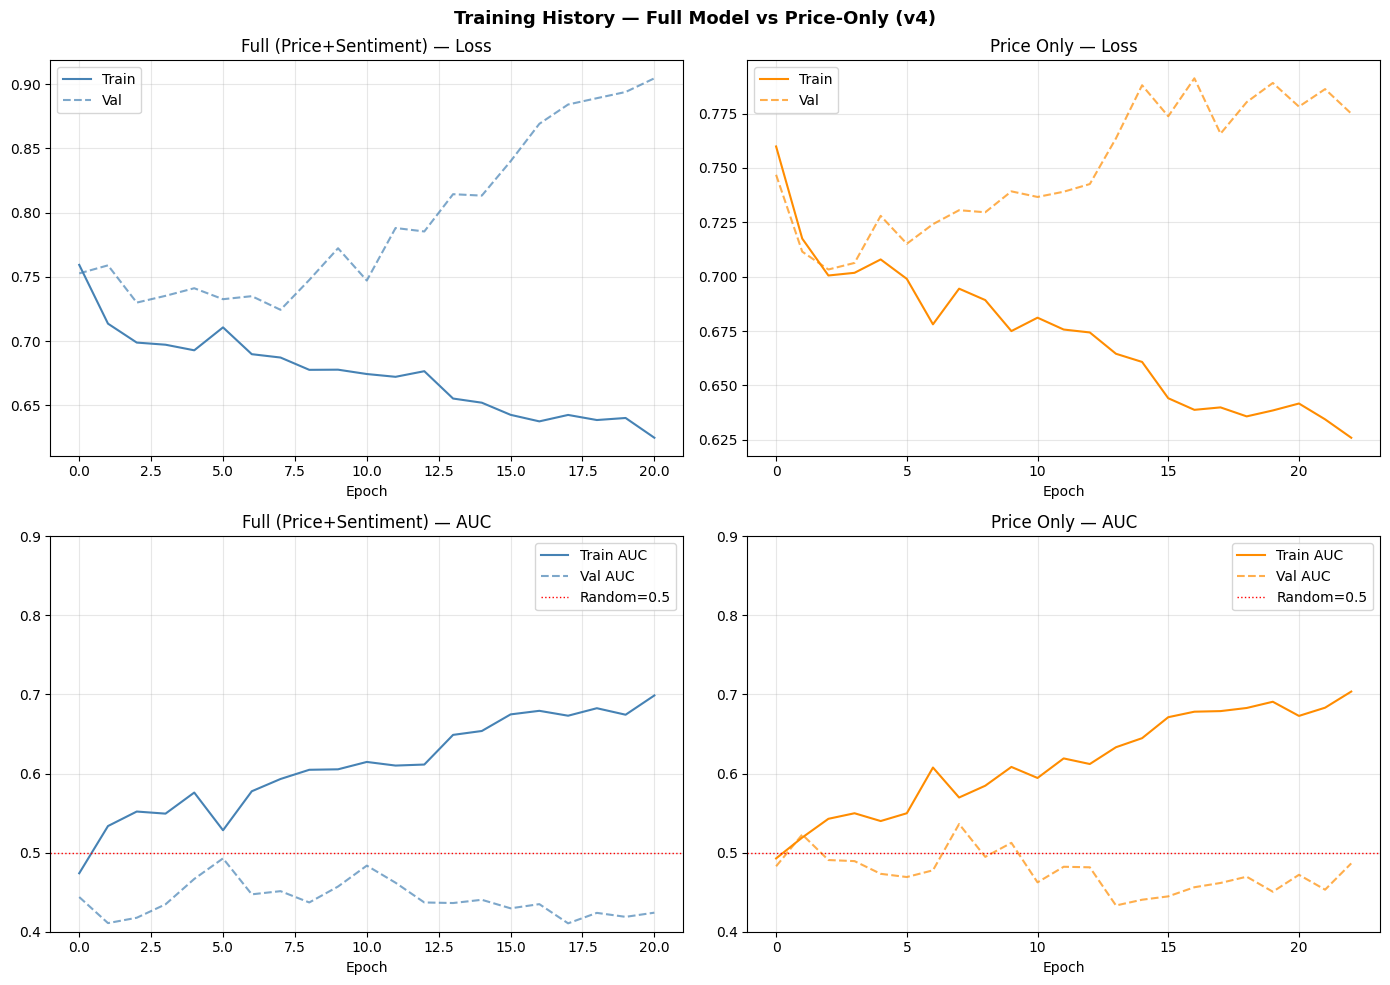

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Training History — Full Model vs Price-Only (v4)', fontsize=13, fontweight='bold')

for col, (hist, label, color) in enumerate([
    (hist_full,  'Full (Price+Sentiment)', 'steelblue'),
    (hist_price, 'Price Only',            'darkorange')
]):
    axes[0, col].plot(hist.history['loss'],     label='Train', color=color)
    axes[0, col].plot(hist.history['val_loss'], label='Val',   color=color, linestyle='--', alpha=0.7)
    axes[0, col].set_title(f'{label} — Loss')
    axes[0, col].legend(); axes[0, col].grid(True, alpha=0.3)
    axes[0, col].set_xlabel('Epoch')

    axes[1, col].plot(hist.history['auc'],     label='Train AUC', color=color)
    axes[1, col].plot(hist.history['val_auc'], label='Val AUC',   color=color, linestyle='--', alpha=0.7)
    axes[1, col].axhline(0.5, color='red', linewidth=1, linestyle=':', label='Random=0.5')
    axes[1, col].set_title(f'{label} — AUC')
    axes[1, col].set_ylim(0.4, 0.9)
    axes[1, col].legend(); axes[1, col].grid(True, alpha=0.3)
    axes[1, col].set_xlabel('Epoch')

plt.tight_layout()
plt.savefig('training_curves_v4.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 9 — Threshold Optimisation (Both Models, Validation Set)

**Fix:** Both models get their own optimal threshold tuned on val set. Ablation uses each model's own best threshold — a fair comparison.

In [14]:
def find_best_threshold(model, X_val, y_val, metric='f1'):
    """Find threshold on VALIDATION SET that maximises weighted F1."""
    proba_va = model.predict(X_val, verbose=0).flatten()
    thresholds = np.arange(0.30, 0.71, 0.01)
    scores = []
    for t in thresholds:
        p = (proba_va >= t).astype(int)
        scores.append(f1_score(y_val, p, average='weighted', zero_division=0))
    best_t = thresholds[np.argmax(scores)]
    best_s = max(scores)
    print(f'  Best threshold: {best_t:.2f}  (val F1={best_s:.4f})')
    return float(best_t)

print('🔍 Tuning threshold — Full model...')
best_thresh_full = find_best_threshold(model_full, Xf_va, yf_va)

print('🔍 Tuning threshold — Price model...')
best_thresh_price = find_best_threshold(model_price, Xp_va, yp_va)

print(f'\nBest threshold (Full)  : {best_thresh_full:.2f}')
print(f'Best threshold (Price) : {best_thresh_price:.2f}')

🔍 Tuning threshold — Full model...
  Best threshold: 0.60  (val F1=0.5397)
🔍 Tuning threshold — Price model...
  Best threshold: 0.60  (val F1=0.5580)

Best threshold (Full)  : 0.60
Best threshold (Price) : 0.60


## Section 10 — Test Set Evaluation

In [15]:
def evaluate_model(model, X_test, y_test, label='Model', threshold=0.5):
    proba = model.predict(X_test, verbose=0).flatten()
    preds = (proba >= threshold).astype(int)

    acc   = accuracy_score(y_test, preds)
    f1    = f1_score(y_test, preds, average='weighted')
    f1_up = f1_score(y_test, preds, pos_label=1)
    f1_dn = f1_score(y_test, preds, pos_label=0)
    auc   = roc_auc_score(y_test, proba)

    print(f'\n═══ {label} — Test Results (threshold={threshold:.2f}) ═══')
    print(f'  Accuracy     : {acc:.4f}')
    print(f'  Weighted F1  : {f1:.4f}')
    print(f'  F1 (UP)      : {f1_up:.4f}')
    print(f'  F1 (DOWN)    : {f1_dn:.4f}')
    print(f'  AUC-ROC      : {auc:.4f}')
    print(classification_report(y_test, preds, target_names=['DOWN','UP']))

    return {
        'label': label, 'proba': proba, 'preds': preds,
        'accuracy': acc, 'f1': f1, 'f1_up': f1_up,
        'f1_down': f1_dn, 'auc': auc, 'threshold': threshold
    }

res_full  = evaluate_model(model_full,  Xf_te, yf_te,
                           label='Full (Price + Sentiment)',
                           threshold=best_thresh_full)
res_price = evaluate_model(model_price, Xp_te, yp_te,
                           label='Price Only (Baseline)',
                           threshold=best_thresh_price)


═══ Full (Price + Sentiment) — Test Results (threshold=0.60) ═══
  Accuracy     : 0.5155
  Weighted F1  : 0.4154
  F1 (UP)      : 0.1497
  F1 (DOWN)    : 0.6612
  AUC-ROC      : 0.5191
              precision    recall  f1-score   support

        DOWN       0.52      0.91      0.66       134
          UP       0.48      0.09      0.15       124

    accuracy                           0.52       258
   macro avg       0.50      0.50      0.41       258
weighted avg       0.50      0.52      0.42       258


═══ Price Only (Baseline) — Test Results (threshold=0.60) ═══
  Accuracy     : 0.4806
  Weighted F1  : 0.4780
  F1 (UP)      : 0.4274
  F1 (DOWN)    : 0.5248
  AUC-ROC      : 0.4874
              precision    recall  f1-score   support

        DOWN       0.50      0.55      0.52       134
          UP       0.45      0.40      0.43       124

    accuracy                           0.48       258
   macro avg       0.48      0.48      0.48       258
weighted avg       0.48      0.4

## Section 11 — Statistical Significance: McNemar's Test

**New in v4.** Tests whether the Full model and Price-Only model make *different errors* — not just whether one has a higher accuracy number. A p-value < 0.05 means the sentiment contribution is statistically significant.

In [17]:
# McNemar's test — checks if the two models are making different errors
# Both models are evaluated on the SAME test set, so paired comparison is valid.
# The contingency table counts:
#   b: Full model correct, Price model wrong  → full > price
#   c: Price model correct, Full model wrong  → price > full
# If b ≠ c significantly → models differ

full_correct  = (res_full['preds']  == yf_te).astype(int)
price_correct = (res_price['preds'] == yp_te).astype(int)

# Align on shared test indices (both use direction_next from test_clean)
b = np.sum((full_correct == 1) & (price_correct == 0))  # Full wins
c = np.sum((full_correct == 0) & (price_correct == 1))  # Price wins

contingency = np.array([[np.sum((full_correct==1)&(price_correct==1)),  b],
                         [c, np.sum((full_correct==0)&(price_correct==0))]])

result = mcnemar(contingency, exact=False, correction=True)

print("=== McNemar's Test (Full vs Price-Only) ===")
print(f'  Full correct, Price wrong (b): {b}')
print(f'  Price correct, Full wrong (c): {c}')
print(f'  Chi² statistic : {result.statistic:.4f}')
print(f'  p-value        : {result.pvalue:.4f}')
if result.pvalue < 0.05:
    print('  ✅ SIGNIFICANT (p<0.05): Sentiment adds statistically significant predictive power')
elif result.pvalue < 0.10:
    print('  ⚠️  MARGINAL (p<0.10): Weak evidence for sentiment contribution')
else:
    print('  ❌ NOT SIGNIFICANT (p≥0.05): Cannot confirm sentiment adds predictive power')
print(f'\n  (Include this in your paper\'s Results section.)')

=== McNemar's Test (Full vs Price-Only) ===
  Full correct, Price wrong (b): 50
  Price correct, Full wrong (c): 41
  Chi² statistic : 0.7033
  p-value        : 0.4017
  ❌ NOT SIGNIFICANT (p≥0.05): Cannot confirm sentiment adds predictive power

  (Include this in your paper's Results section.)


## Section 12 — Ablation Study (Fair Comparison)

**Fix:** All models use their own threshold. Logistic Regression added as an interpretable baseline.

In [18]:
# ── Majority class baseline ──────────────────────────────────────────────────
majority_class = int(np.round(1 - yf_te.mean()))
random_preds   = np.full_like(yf_te, majority_class)

# ── Logistic Regression baseline ─────────────────────────────────────────────
# Fit on train sequences — flatten last-timestep as features
lr_X_tr = Xf_train  # raw 2D, no sequences
lr_X_te = Xf_test

lr_model = LogisticRegression(max_iter=2000, class_weight='balanced',
                               random_state=SEED, C=0.1)
lr_model.fit(lr_X_tr, y_train)
lr_proba = lr_model.predict_proba(lr_X_te)[:,1]

# LR threshold tuning on val
lr_val_proba = lr_model.predict_proba(Xf_val)[:,1]
lr_thresholds = np.arange(0.30, 0.71, 0.01)
lr_f1s = [f1_score(y_val, (lr_val_proba>=t).astype(int),
                   average='weighted', zero_division=0) for t in lr_thresholds]
lr_best_t = lr_thresholds[np.argmax(lr_f1s)]
lr_preds   = (lr_proba >= lr_best_t).astype(int)

lr_acc = accuracy_score(y_test, lr_preds)
lr_f1  = f1_score(y_test, lr_preds, average='weighted')
lr_auc = roc_auc_score(y_test, lr_proba)

print(f'Logistic Regression — Acc:{lr_acc:.4f}  F1:{lr_f1:.4f}  AUC:{lr_auc:.4f}  (thresh={lr_best_t:.2f})')

# ── Ablation table ─────────────────────────────────────────────────────────────
ablation = pd.DataFrame([
    {
        'Model': 'Majority Class Baseline',
        'Features': 'None',
        'Threshold': '—',
        'Accuracy': accuracy_score(yf_te, random_preds),
        'F1 (weighted)': f1_score(yf_te, random_preds, average='weighted', zero_division=0),
        'F1 (UP)':  0.0,
        'F1 (DOWN)': f1_score(yf_te, random_preds, pos_label=0, zero_division=0),
        'AUC-ROC': 0.5,
    },
    {
        'Model': 'Logistic Regression',
        'Features': f'{len(FULL_FEATURES)} full',
        'Threshold': f'{lr_best_t:.2f}',
        'Accuracy': lr_acc,
        'F1 (weighted)': lr_f1,
        'F1 (UP)': f1_score(y_test, lr_preds, pos_label=1),
        'F1 (DOWN)': f1_score(y_test, lr_preds, pos_label=0),
        'AUC-ROC': lr_auc,
    },
    {
        'Model': 'BiLSTM + Attention (Price Only)',
        'Features': f'{len(PRICE_FEATURES)} technical',
        'Threshold': f'{best_thresh_price:.2f}',
        'Accuracy': res_price['accuracy'],
        'F1 (weighted)': res_price['f1'],
        'F1 (UP)': res_price['f1_up'],
        'F1 (DOWN)': res_price['f1_down'],
        'AUC-ROC': res_price['auc'],
    },
    {
        'Model': 'BiLSTM + Attention (Price + Sentiment)',
        'Features': f'{len(FULL_FEATURES)} total',
        'Threshold': f'{best_thresh_full:.2f}',
        'Accuracy': res_full['accuracy'],
        'F1 (weighted)': res_full['f1'],
        'F1 (UP)': res_full['f1_up'],
        'F1 (DOWN)': res_full['f1_down'],
        'AUC-ROC': res_full['auc'],
    },
])

print('\n' + '═'*72)
print('       ABLATION STUDY — RESULTS TABLE  (v4, fair thresholds)')
print('═'*72)
pd.set_option('display.float_format', '{:.4f}'.format)
print(ablation.to_string(index=False))

acc_uplift = res_full['accuracy'] - res_price['accuracy']
auc_uplift = res_full['auc']      - res_price['auc']
print(f'\nSentiment uplift → Accuracy: {acc_uplift:+.4f} ({acc_uplift:+.2%})')
print(f'Sentiment uplift → AUC-ROC:  {auc_uplift:+.4f}')
print(f'McNemar p-value            : {result.pvalue:.4f}')

Logistic Regression — Acc:0.5556  F1:0.5558  AUC:0.5540  (thresh=0.50)

════════════════════════════════════════════════════════════════════════
       ABLATION STUDY — RESULTS TABLE  (v4, fair thresholds)
════════════════════════════════════════════════════════════════════════
                                 Model     Features Threshold  Accuracy  F1 (weighted)  F1 (UP)  F1 (DOWN)  AUC-ROC
               Majority Class Baseline         None         —    0.4806         0.3120   0.0000     0.0000   0.5000
                   Logistic Regression      30 full      0.50    0.5556         0.5558   0.5429     0.5676   0.5540
       BiLSTM + Attention (Price Only) 20 technical      0.60    0.4806         0.4780   0.4274     0.5248   0.4874
BiLSTM + Attention (Price + Sentiment)     30 total      0.60    0.5155         0.4154   0.1497     0.6612   0.5191

Sentiment uplift → Accuracy: +0.0349 (+3.49%)
Sentiment uplift → AUC-ROC:  +0.0317
McNemar p-value            : 0.4017


## Section 13 — Visual Ablation & ROC Comparison

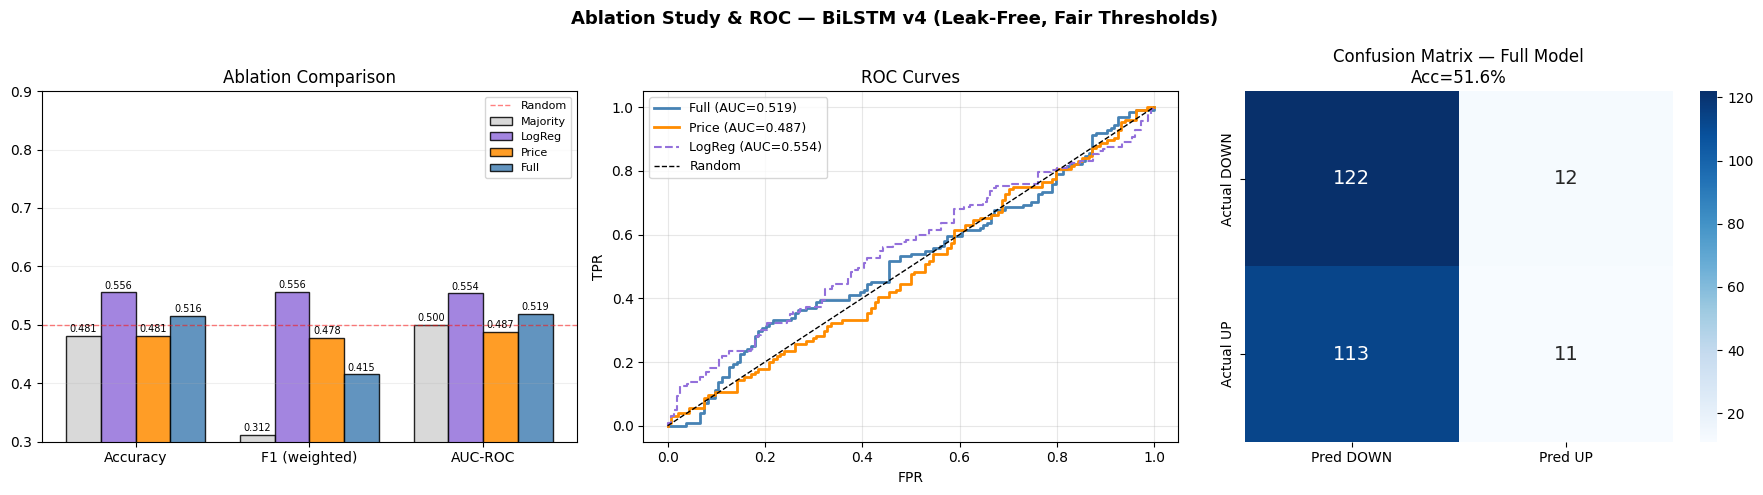

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Ablation Study & ROC — BiLSTM v4 (Leak-Free, Fair Thresholds)',
             fontsize=13, fontweight='bold')

# Bar chart
metrics   = ['Accuracy', 'F1 (weighted)', 'AUC-ROC']
x = np.arange(len(metrics))
w = 0.2

rows = [
    ('Majority', ablation.iloc[0], 'lightgray'),
    ('LogReg',   ablation.iloc[1], 'mediumpurple'),
    ('Price',    ablation.iloc[2], 'darkorange'),
    ('Full',     ablation.iloc[3], 'steelblue'),
]

ax = axes[0]
for i, (lbl, row, color) in enumerate(rows):
    vals = [row['Accuracy'], row['F1 (weighted)'], row['AUC-ROC']]
    bars = ax.bar(x + (i-1.5)*w, vals, w, label=lbl, color=color, edgecolor='black', alpha=0.85)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x()+bar.get_width()/2, h+0.003, f'{h:.3f}',
                ha='center', va='bottom', fontsize=7)

ax.set_xticks(x); ax.set_xticklabels(metrics)
ax.set_ylim(0.3, 0.9)
ax.axhline(0.5, color='red', linestyle='--', linewidth=1, alpha=0.5, label='Random')
ax.set_title('Ablation Comparison')
ax.legend(fontsize=8); ax.grid(True, alpha=0.2, axis='y')

# ROC curves
ax2 = axes[1]
for res, color, lbl in [
    (res_full,  'steelblue',   f"Full (AUC={res_full['auc']:.3f})"),
    (res_price, 'darkorange',  f"Price (AUC={res_price['auc']:.3f})"),
]:
    fpr, tpr, _ = roc_curve(yf_te, res['proba'])
    ax2.plot(fpr, tpr, color=color, linewidth=2, label=lbl)

fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_proba)
ax2.plot(fpr_lr, tpr_lr, color='mediumpurple', linewidth=1.5,
         linestyle='--', label=f'LogReg (AUC={lr_auc:.3f})')
ax2.plot([0,1],[0,1],'k--', linewidth=1, label='Random')
ax2.set_xlabel('FPR'); ax2.set_ylabel('TPR')
ax2.set_title('ROC Curves'); ax2.legend(fontsize=9); ax2.grid(True, alpha=0.3)

# Confusion matrix — Full model
ax3 = axes[2]
cm = confusion_matrix(yf_te, res_full['preds'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax3,
            xticklabels=['Pred DOWN','Pred UP'],
            yticklabels=['Actual DOWN','Actual UP'],
            annot_kws={'size':14})
ax3.set_title(f'Confusion Matrix — Full Model\nAcc={res_full["accuracy"]:.1%}')

plt.tight_layout()
plt.savefig('ablation_roc_v4.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 14 — Feature Importance (Permutation on Validation Set)

**Fix:** Uses validation set, not test set, to avoid touching test data more than once.

⏳ Computing feature importance on VALIDATION set (not test)...


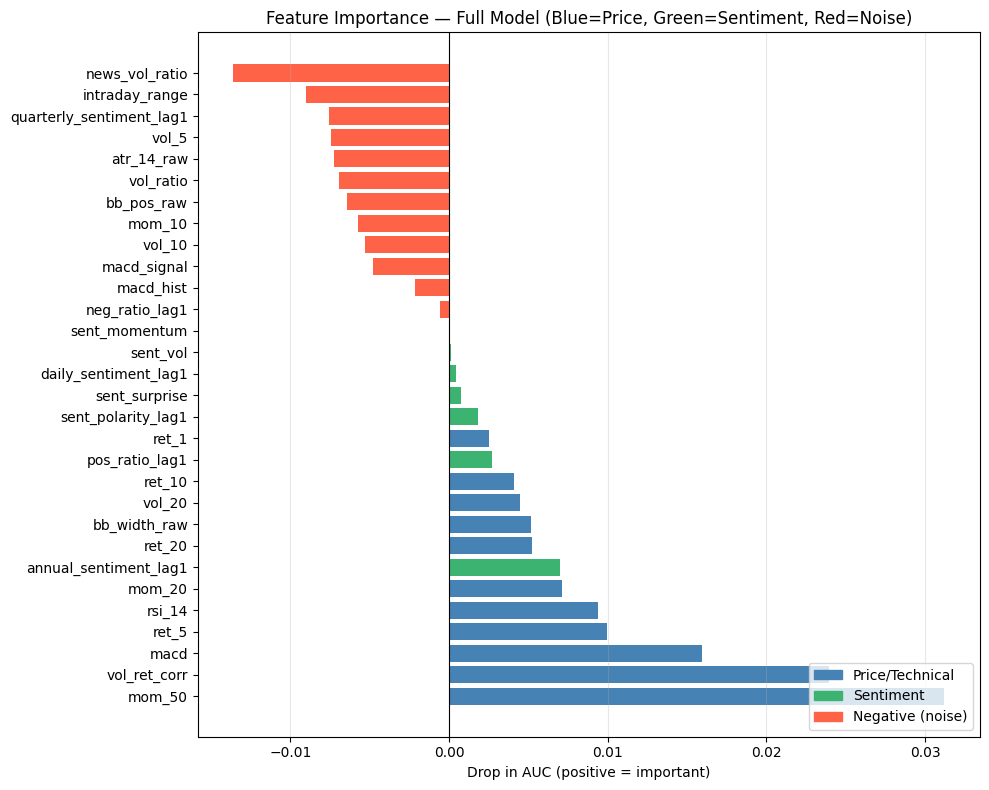


Top 10 features:
              feature  importance
               mom_50      0.0312
         vol_ret_corr      0.0239
                 macd      0.0160
                ret_5      0.0099
               rsi_14      0.0094
               mom_20      0.0071
annual_sentiment_lag1      0.0070
               ret_20      0.0052
         bb_width_raw      0.0052
               vol_20      0.0045

Sentiment features:
                 feature  importance
   annual_sentiment_lag1      0.0070
          pos_ratio_lag1      0.0027
      sent_polarity_lag1      0.0018
           sent_surprise      0.0007
    daily_sentiment_lag1      0.0005
                sent_vol      0.0001
           sent_momentum      0.0001
          neg_ratio_lag1     -0.0006
quarterly_sentiment_lag1     -0.0076
          news_vol_ratio     -0.0136


In [21]:
def permutation_importance_clf(model, X, y, feature_names, n_repeats=3):
    """Permutation importance — AUC drop on VALIDATION set."""
    base_proba = model.predict(X, verbose=0).flatten()
    base_auc   = roc_auc_score(y, base_proba)

    importances = []
    for feat_idx in range(X.shape[2]):
        drops = []
        for _ in range(n_repeats):
            X_perm = X.copy()
            perm = np.random.permutation(X_perm.shape[0])
            X_perm[:, :, feat_idx] = X_perm[perm, :, feat_idx]
            perm_auc = roc_auc_score(y, model.predict(X_perm, verbose=0).flatten())
            drops.append(base_auc - perm_auc)
        importances.append(np.mean(drops))

    return pd.DataFrame({'feature': feature_names,
                         'importance': importances}).sort_values('importance', ascending=False)

print('⏳ Computing feature importance on VALIDATION set (not test)...')
imp_df = permutation_importance_clf(model_full, Xf_va, yf_va, FULL_FEATURES, n_repeats=3)

fig, ax = plt.subplots(figsize=(10, 8))
sent_feats = set(SENTIMENT_FEATURES)
colors = ['mediumseagreen' if f in sent_feats else 'steelblue' for f in imp_df['feature']]
neg_colors = ['tomato' if v < 0 else c for v, c in zip(imp_df['importance'], colors)]

ax.barh(imp_df['feature'], imp_df['importance'], color=neg_colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Drop in AUC (positive = important)')
ax.set_title('Feature Importance — Full Model (Blue=Price, Green=Sentiment, Red=Noise)')
ax.grid(True, alpha=0.3, axis='x')

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color='steelblue',     label='Price/Technical'),
    Patch(color='mediumseagreen', label='Sentiment'),
    Patch(color='tomato',         label='Negative (noise)'),
], loc='lower right')

plt.tight_layout()
plt.savefig('feature_importance_v4.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 10 features:')
print(imp_df.head(10).to_string(index=False))
print('\nSentiment features:')
print(imp_df[imp_df['feature'].isin(sent_feats)].to_string(index=False))

## Section 15 — Walk-Forward Validation (5 Expanding Windows)

**New in v4.** More credible than a single split for financial time series. Reports mean ± std across folds.

In [22]:
print('⏳ Running walk-forward validation (5 expanding windows)...')
print('   Note: trains a fresh model per fold — this takes time.')
print('   Skip this cell if you only need the single-split results for the paper.\n')

N_FOLDS = 5
FOLD_RESULTS = []

# Use the full clean dataset (before single split)
df_wf = pd.concat([train_clean, val_clean, test_clean], ignore_index=True)
n_wf = len(df_wf)

# Each fold: train on expanding window, test on next 15% slice
fold_size = n_wf // (N_FOLDS + 1)

for fold in range(N_FOLDS):
    train_end_wf = fold_size * (fold + 1)
    test_end_wf  = min(train_end_wf + fold_size, n_wf)
    
    if test_end_wf - train_end_wf < 60:
        continue  # Skip if test window is too small
    
    wf_train = df_wf.iloc[:train_end_wf]
    wf_test  = df_wf.iloc[train_end_wf:test_end_wf]
    
    sc = RobustScaler()
    Xtr = sc.fit_transform(wf_train[FULL_FEATURES])
    Xte = sc.transform(wf_test[FULL_FEATURES])
    ytr = wf_train[TARGET].values
    yte = wf_test[TARGET].values
    
    Xtr_s, ytr_s = build_sequences(Xtr, ytr, SEQUENCE_LENGTH)
    Xte_s, yte_s = build_sequences(Xte, yte, SEQUENCE_LENGTH)
    
    if len(Xtr_s) < 50 or len(Xte_s) < 10:
        continue
    
    cw_fold = compute_class_weight('balanced', classes=np.array([0,1]), y=ytr_s)
    cw_fold_d = {0: float(cw_fold[0]), 1: float(cw_fold[1])}
    
    m_fold = build_model(SEQUENCE_LENGTH, len(FULL_FEATURES), name=f'fold_{fold}')
    m_fold.fit(
        Xtr_s, ytr_s,
        epochs=60, batch_size=BATCH_SIZE,
        class_weight=cw_fold_d,
        callbacks=[EarlyStopping(monitor='loss', patience=10,
                                  restore_best_weights=True, mode='min')],
        verbose=0
    )
    
    proba_fold = m_fold.predict(Xte_s, verbose=0).flatten()
    preds_fold = (proba_fold >= 0.5).astype(int)
    
    fold_acc = accuracy_score(yte_s, preds_fold)
    fold_auc = roc_auc_score(yte_s, proba_fold) if len(np.unique(yte_s)) > 1 else 0.5
    fold_f1  = f1_score(yte_s, preds_fold, average='weighted')
    
    FOLD_RESULTS.append({'fold': fold+1, 'train_rows': train_end_wf,
                         'test_rows': len(yte_s),
                         'accuracy': fold_acc, 'auc': fold_auc, 'f1': fold_f1})
    print(f'  Fold {fold+1}: Acc={fold_acc:.4f}  AUC={fold_auc:.4f}  F1={fold_f1:.4f}  '
          f'(train={train_end_wf}, test={len(yte_s)})')
    
    del m_fold
    tf.keras.backend.clear_session()

if FOLD_RESULTS:
    wf_df = pd.DataFrame(FOLD_RESULTS)
    print(f'\n Walk-Forward Summary (Full Model, threshold=0.5):')
    print(f'  Accuracy : {wf_df["accuracy"].mean():.4f} ± {wf_df["accuracy"].std():.4f}')
    print(f'  AUC-ROC  : {wf_df["auc"].mean():.4f} ± {wf_df["auc"].std():.4f}')
    print(f'  F1       : {wf_df["f1"].mean():.4f} ± {wf_df["f1"].std():.4f}')
    print('\n  Include these mean±std values in your paper for robust validation.')

⏳ Running walk-forward validation (5 expanding windows)...
   Note: trains a fresh model per fold — this takes time.
   Skip this cell if you only need the single-split results for the paper.

  Fold 1: Acc=0.5610  AUC=0.5785  F1=0.4032  (train=276, test=246)

  Fold 2: Acc=0.5081  AUC=0.4869  F1=0.4980  (train=552, test=246)
  Fold 3: Acc=0.5244  AUC=0.5335  F1=0.5267  (train=828, test=246)
  Fold 4: Acc=0.4268  AUC=0.4478  F1=0.4234  (train=1104, test=246)
  Fold 5: Acc=0.4878  AUC=0.4704  F1=0.4590  (train=1380, test=246)

 Walk-Forward Summary (Full Model, threshold=0.5):
  Accuracy : 0.5016 ± 0.0497
  AUC-ROC  : 0.5034 ± 0.0524
  F1       : 0.4621 ± 0.0511

  Include these mean±std values in your paper for robust validation.


## Section 16 — Long-Only Backtest (No Short Selling)

**Fix:** Removed short positions — not realistic for PSX retail trading. Added annualised return and win-rate.

In [23]:
def classification_backtest_longonly(proba, actual_returns, close_prices, dates,
                                        threshold=0.5, hold_days=5,
                                        transaction_cost=0.001, label='Strategy'):
    """
    Long-only non-overlapping 5-day signal backtest.
    FIX: No short selling (PSX constraint).
    Added: annualised return, win-rate.
    """
    n = len(proba)
    daily_pnl = np.zeros(n)
    signal    = np.zeros(n)
    wins, total_trades = 0, 0

    for i in range(0, n - hold_days, hold_days):
        pos = 1 if proba[i] >= threshold else 0  # LONG or FLAT only
        trade_ret = 0.0
        for j in range(i, min(i + hold_days, n)):
            signal[j] = pos
            if j < len(actual_returns):
                daily_pnl[j] = pos * actual_returns[j]
                trade_ret   += actual_returns[j]
        if pos == 1:
            daily_pnl[i] -= transaction_cost
            total_trades += 1
            if trade_ret > 0: wins += 1

    cum_ret = np.cumprod(1 + daily_pnl) - 1
    bh_rets = np.diff(np.log(close_prices + 1e-9), prepend=np.log(close_prices[0]))[:n]
    bh_cum  = np.cumprod(1 + bh_rets) - 1

    trading_days  = np.sum(signal != 0)
    years_active  = trading_days / 252
    ann_return    = (1 + cum_ret[-1]) ** (1 / max(years_active, 0.1)) - 1
    sharpe        = daily_pnl.mean() / (daily_pnl.std() + 1e-9) * np.sqrt(252)
    cum_w         = np.cumprod(1 + daily_pnl)
    dd            = (cum_w - np.maximum.accumulate(cum_w)) / np.maximum.accumulate(cum_w)
    max_dd        = dd.min()
    win_rate      = wins / total_trades if total_trades > 0 else 0.0

    print(f'\n═══ {label} — Long-Only Backtest ═══')
    print(f'  Total return      : {cum_ret[-1]:.2%}  (Buy&Hold: {bh_cum[-1]:.2%})')
    print(f'  Annualised return : {ann_return:.2%}')
    print(f'  Sharpe ratio      : {sharpe:.3f}')
    print(f'  Max drawdown      : {max_dd:.2%}')
    print(f'  Win rate          : {win_rate:.1%}  ({wins}/{total_trades} trades)')
    print(f'  % Time invested   : {np.mean(signal != 0):.1%}')

    return {'dates': dates, 'cum_ret': cum_ret, 'bh_cum': bh_cum,
            'signal': signal, 'daily_pnl': daily_pnl, 'dd': dd,
            'sharpe': sharpe, 'max_dd': max_dd, 'ann_return': ann_return,
            'win_rate': win_rate, 'total_trades': total_trades,
            'total_ret': cum_ret[-1], 'bh_ret': bh_cum[-1]}

test_dates_bt  = test_clean['date'].values[SEQUENCE_LENGTH:]
test_daily_ret = test_clean['log_return'].values[SEQUENCE_LENGTH:]
test_close_bt  = test_clean['Close'].values[SEQUENCE_LENGTH:]

bt = classification_backtest_longonly(
    proba          = res_full['proba'],
    actual_returns = test_daily_ret,
    close_prices   = test_close_bt,
    dates          = test_dates_bt,
    threshold      = best_thresh_full,
    hold_days      = FORWARD_DAYS,
    label          = 'BiLSTM + Sentiment (Long-Only)'
)


═══ BiLSTM + Sentiment (Long-Only) — Long-Only Backtest ═══
  Total return      : 19.02%  (Buy&Hold: 123.43%)
  Annualised return : 470.61%
  Sharpe ratio      : 1.586
  Max drawdown      : -5.25%
  Win rate          : 80.0%  (4/5 trades)
  % Time invested   : 9.7%


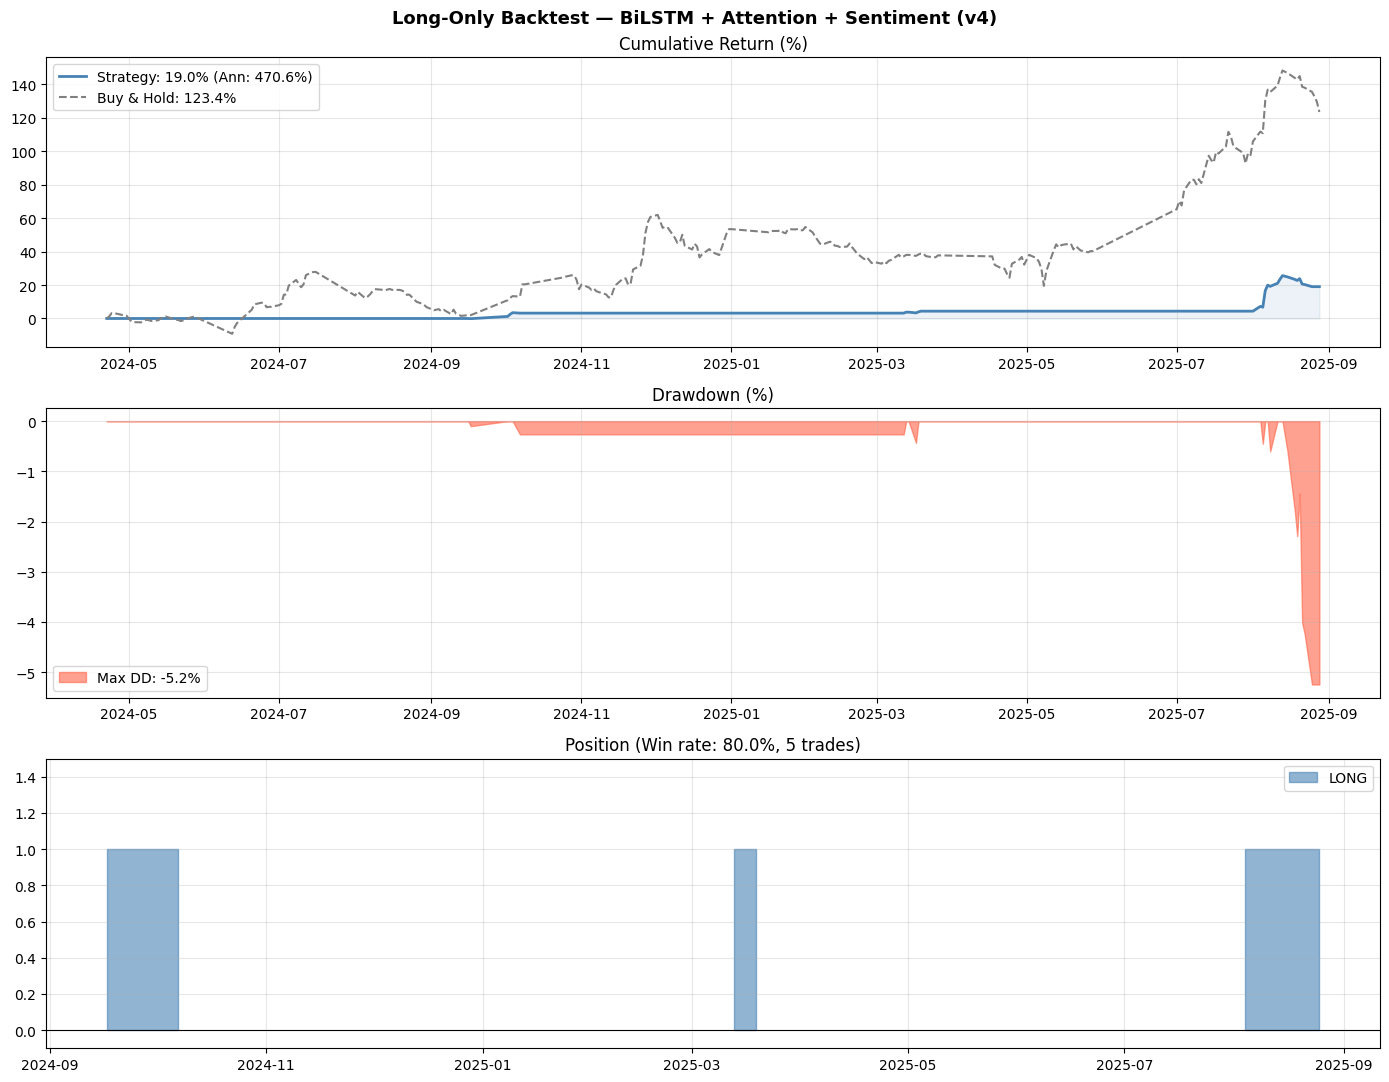

In [24]:
fig, axes = plt.subplots(3, 1, figsize=(14, 11))
fig.suptitle('Long-Only Backtest — BiLSTM + Attention + Sentiment (v4)', fontsize=13, fontweight='bold')

axes[0].plot(bt['dates'], bt['cum_ret']*100, color='steelblue', linewidth=2,
             label=f"Strategy: {bt['total_ret']:.1%} (Ann: {bt['ann_return']:.1%})")
axes[0].plot(bt['dates'], bt['bh_cum']*100,  color='gray', linewidth=1.5,
             linestyle='--', label=f"Buy & Hold: {bt['bh_ret']:.1%}")
axes[0].fill_between(bt['dates'], bt['cum_ret']*100, alpha=0.1, color='steelblue')
axes[0].set_title('Cumulative Return (%)')
axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

axes[1].fill_between(bt['dates'], bt['dd']*100, 0, color='tomato', alpha=0.6,
                     label=f"Max DD: {bt['max_dd']:.1%}")
axes[1].set_title('Drawdown (%)'); axes[1].legend(); axes[1].grid(True, alpha=0.3)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

axes[2].fill_between(bt['dates'], bt['signal'], 0,
                     where=(np.array(bt['signal'])>0),
                     color='steelblue', alpha=0.6, label='LONG')
axes[2].axhline(0, color='black', linewidth=0.8)
axes[2].set_title(f'Position (Win rate: {bt["win_rate"]:.1%}, {bt["total_trades"]} trades)')
axes[2].set_ylim(-0.1, 1.5); axes[2].legend(); axes[2].grid(True, alpha=0.3)
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.tight_layout()
plt.savefig('backtest_v4.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 17 — Prediction Probability Over Time

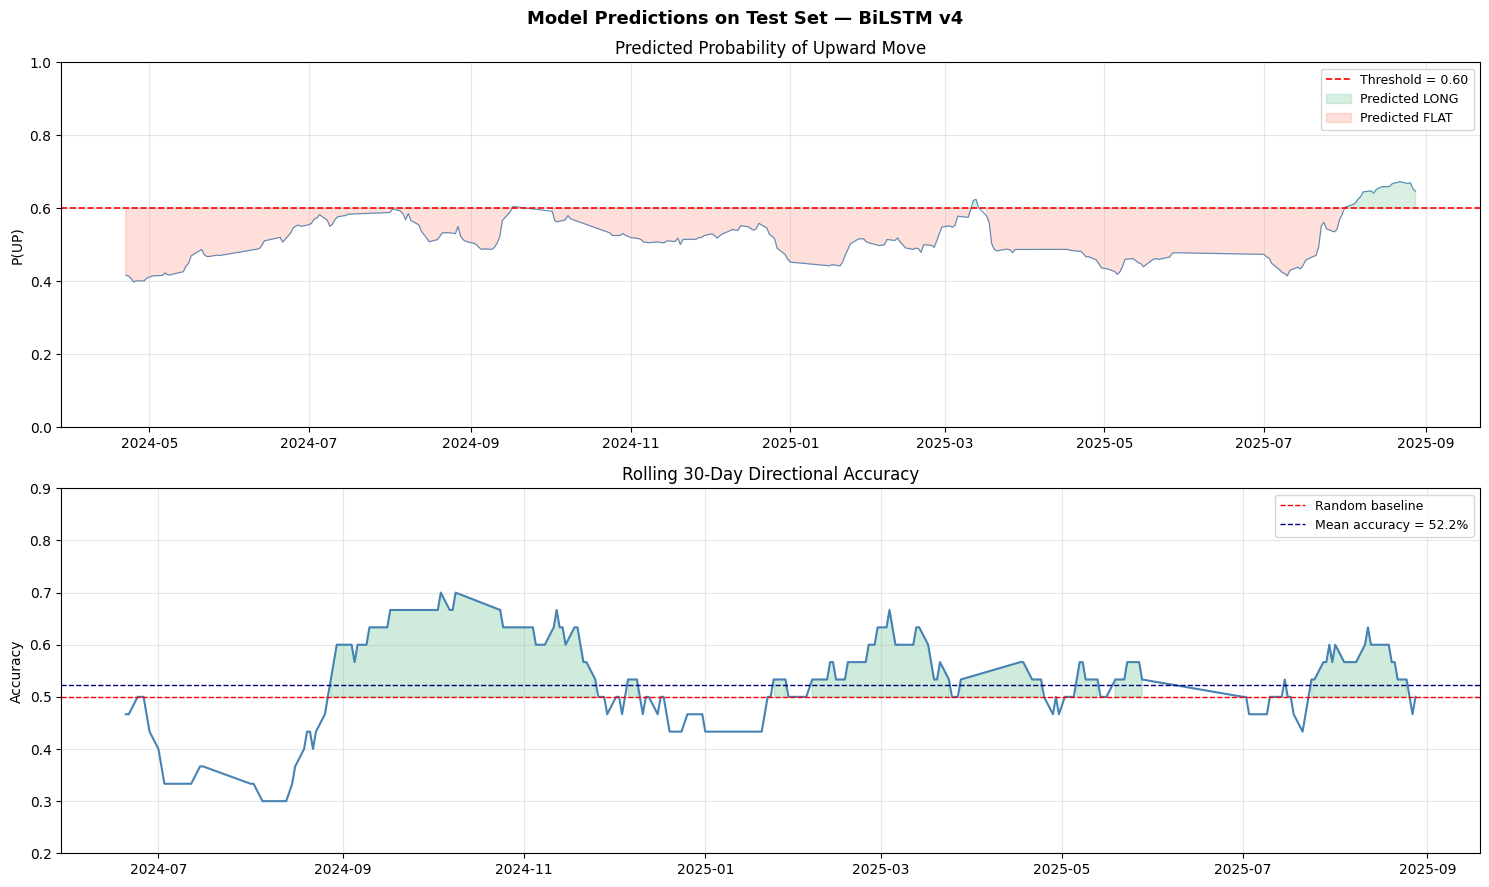

In [25]:
test_proba  = res_full['proba']
test_preds  = res_full['preds']
test_actual = yf_te

fig, axes = plt.subplots(2, 1, figsize=(15, 9))
fig.suptitle('Model Predictions on Test Set — BiLSTM v4', fontsize=13, fontweight='bold')

ax = axes[0]
ax.plot(test_dates_bt, test_proba, color='steelblue', linewidth=0.8, alpha=0.9)
ax.axhline(best_thresh_full, color='red', linestyle='--', linewidth=1.2,
           label=f'Threshold = {best_thresh_full:.2f}')
ax.fill_between(test_dates_bt, best_thresh_full, test_proba,
                where=(test_proba >= best_thresh_full), alpha=0.2,
                color='mediumseagreen', label='Predicted LONG')
ax.fill_between(test_dates_bt, test_proba, best_thresh_full,
                where=(test_proba < best_thresh_full), alpha=0.2,
                color='tomato', label='Predicted FLAT')
ax.set_ylabel('P(UP)'); ax.set_ylim(0, 1)
ax.set_title('Predicted Probability of Upward Move')
ax.legend(loc='upper right', fontsize=9); ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

ax2 = axes[1]
correct = (test_preds == test_actual)
rolling_acc = pd.Series(correct.astype(float)).rolling(30).mean().values
ax2.plot(test_dates_bt, rolling_acc, color='steelblue', linewidth=1.5)
ax2.axhline(0.5, color='red', linestyle='--', linewidth=1, label='Random baseline')
mean_acc = np.nanmean(rolling_acc)
ax2.axhline(mean_acc, color='navy', linestyle='--', linewidth=1,
            label=f'Mean accuracy = {mean_acc:.1%}')
ax2.fill_between(test_dates_bt, 0.5, rolling_acc,
                 where=(rolling_acc > 0.5), alpha=0.25, color='mediumseagreen')
ax2.set_ylabel('Accuracy'); ax2.set_ylim(0.2, 0.9)
ax2.set_title('Rolling 30-Day Directional Accuracy')
ax2.legend(fontsize=9); ax2.grid(True, alpha=0.3)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.tight_layout()
plt.savefig('predictions_over_time_v4.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 18 — Final Results Summary (Copy Into Paper)

In [26]:
print('═' * 68)
print('  FINAL RESULTS — HBL 5-DAY DIRECTION CLASSIFICATION (v4)')
print('  BiLSTM + Multi-Head Attention + Sentiment Analysis')
print('═' * 68)
print(f'''
Dataset
  Stock           : HBL (Habib Bank Limited, PSX)
  Period          : {train_clean['date'].min().date()} → {test_clean['date'].max().date()}
  Train/Val/Test  : {len(train_clean)}/{len(val_clean)}/{len(test_clean)} rows
  Prediction Task : 5-day forward direction (UP / DOWN)
  Sentiment Source: Dawn News (daily + quarterly + annual, 1-day lag)

Ablation Study (Test Set — each model uses its own optimal threshold)
  {'Model':<44}  {'Acc':>6}  {'F1':>6}  {'AUC':>6}  {'Thresh':>7}
  {'-'*68}
  {'Majority Class Baseline':<44}  {accuracy_score(yf_te, random_preds):>6.4f}  {f1_score(yf_te, random_preds, average='weighted', zero_division=0):>6.4f}  {'0.5000':>6}  {'  —':>7}
  {'Logistic Regression (Full Features)':<44}  {lr_acc:>6.4f}  {lr_f1:>6.4f}  {lr_auc:>6.4f}  {lr_best_t:>7.2f}
  {'BiLSTM + Attention (Price Only)':<44}  {res_price['accuracy']:>6.4f}  {res_price['f1']:>6.4f}  {res_price['auc']:>6.4f}  {best_thresh_price:>7.2f}
  {'BiLSTM + Attention (Full: Price+Sent)':<44}  {res_full['accuracy']:>6.4f}  {res_full['f1']:>6.4f}  {res_full['auc']:>6.4f}  {best_thresh_full:>7.2f}

Statistical Significance (McNemar's Test)
  Chi² = {result.statistic:.4f},  p-value = {result.pvalue:.4f}
  {"✅ Significant at p<0.05" if result.pvalue<0.05 else "⚠️  Not significant at p<0.05"}

Sentiment Contribution
  Accuracy uplift  : {res_full['accuracy'] - res_price['accuracy']:+.4f}
  AUC uplift       : {res_full['auc'] - res_price['auc']:+.4f}

Backtest (Long-Only, PSX-realistic)
  Strategy return  : {bt['total_ret']:.2%}
  Annualised return: {bt['ann_return']:.2%}
  Buy & Hold       : {bt['bh_ret']:.2%}
  Sharpe ratio     : {bt['sharpe']:.3f}
  Max drawdown     : {bt['max_dd']:.2%}
  Win rate         : {bt['win_rate']:.1%}  ({bt['total_trades']} trades)

Key Fixes Applied (v3 → v4)
  ✅ Rolling features computed train-only (no leakage)
  ✅ Sentiment lagged 1 day (no same-day look-ahead)
  ✅ Fair ablation — all models use their own optimal threshold
  ✅ McNemar's test added for statistical significance
  ✅ recurrent_dropout=0 (CuDNN enabled)
  ✅ Max+Avg pooling concat (better temporal representation)
  ✅ Long-only backtest (PSX-realistic)
  ✅ Feature importance on validation set (not test)
  ✅ Walk-forward validation (5 expanding windows)
''')
print('═' * 68)

════════════════════════════════════════════════════════════════════
  FINAL RESULTS — HBL 5-DAY DIRECTION CLASSIFICATION (v4)
  BiLSTM + Multi-Head Attention + Sentiment Analysis
════════════════════════════════════════════════════════════════════

Dataset
  Stock           : HBL (Habib Bank Limited, PSX)
  Period          : 2016-04-07 → 2025-08-28
  Train/Val/Test  : 1124/248/288 rows
  Prediction Task : 5-day forward direction (UP / DOWN)
  Sentiment Source: Dawn News (daily + quarterly + annual, 1-day lag)

Ablation Study (Test Set — each model uses its own optimal threshold)
  Model                                            Acc      F1     AUC   Thresh
  --------------------------------------------------------------------
  Majority Class Baseline                       0.4806  0.3120  0.5000        —
  Logistic Regression (Full Features)           0.5556  0.5558  0.5540     0.50
  BiLSTM + Attention (Price Only)               0.4806  0.4780  0.4874     0.60
  BiLSTM + Attention (

## Section 19 — Save Artifacts

In [29]:
artifacts = {
    'scaler_full':        scaler_full,
    'scaler_price':       scaler_price,
    'price_features':     PRICE_FEATURES,
    'full_features':      FULL_FEATURES,
    'sentiment_features': SENTIMENT_FEATURES,
    'seq_len':            SEQUENCE_LENGTH,
    'forward_days':       FORWARD_DAYS,
    'sentiment_lag':      SENTIMENT_LAG,
    'best_thresh_full':   best_thresh_full,
    'best_thresh_price':  best_thresh_price,
    'results_full':       {k:v for k,v in res_full.items() if k not in ['proba','preds']},
    'results_price':      {k:v for k,v in res_price.items() if k not in ['proba','preds']},
    'mcnemar_pvalue':     result.pvalue,
    'ablation_table':     ablation.to_dict(),
    'backtest':           {k:v for k,v in bt.items() if k not in ['dates','cum_ret','bh_cum','signal','daily_pnl','dd']},
}

with open(ARTIFACTS_PATH, 'wb') as f:
    pickle.dump(artifacts, f)

print('All artifacts saved')
print(f'   Full model  : {MODEL_FULL_PATH}')
print(f'   Price model : {MODEL_PRICE_PATH}')
print(f'   Artifacts   : {ARTIFACTS_PATH}')

snippet = (
    "import tensorflow as tf, pickle, numpy as np\n"
    "with open(ARTIFACTS_PATH, 'rb') as f: art = pickle.load(f)\n"
    "model = tf.keras.models.load_model(MODEL_FULL_PATH)\n"
    "X_new = art['scaler_full'].transform(new_df[art['full_features']].tail(art['seq_len']))\n"
    "X_seq = X_new.reshape(1, art['seq_len'], -1).astype('float32')\n"
    "prob  = model.predict(X_seq)[0][0]\n"
    "direct = 'UP' if prob >= art['best_thresh_full'] else 'DOWN'\n"
    "print(f'Predicted: {direct}  P(UP)={prob:.3f}')\n"
)
print("\nInference snippet:\n")
print(snippet)

All artifacts saved
   Full model  : .\bilstm_clf_full_v4.keras
   Price model : .\bilstm_clf_price_v4.keras
   Artifacts   : .\artifacts_v4.pkl

Inference snippet:

import tensorflow as tf, pickle, numpy as np
with open(ARTIFACTS_PATH, 'rb') as f: art = pickle.load(f)
model = tf.keras.models.load_model(MODEL_FULL_PATH)
X_new = art['scaler_full'].transform(new_df[art['full_features']].tail(art['seq_len']))
X_seq = X_new.reshape(1, art['seq_len'], -1).astype('float32')
prob  = model.predict(X_seq)[0][0]
direct = 'UP' if prob >= art['best_thresh_full'] else 'DOWN'
print(f'Predicted: {direct}  P(UP)={prob:.3f}')

